# IndustryGPT: Retail and E-Commerce Support Bot

**Project type:** Industry-specific LLM fine-tuning and conversational AI  
**Industry:** Retail and e-commerce  
**Model:** TinyLlama-1.1B-Chat  
**Author:** Ali Hamza Habib


## Project summary

This project builds a retail and e-commerce support bot by fine-tuning a compact pre-trained language model on public customer-support data. The bot is intended to help with common retail questions such as adding items to a cart, returns, delivery, payments, and account-related tasks. It uses QLoRA, a memory-efficient fine-tuning method, so that the work can run on a Google Colab T4 GPU.

The project focuses on helpful general guidance rather than access to live retailer systems.


## Problem statement

Retail customers often need quick help with routine questions, but a generic chatbot may not understand the language and procedures used in e-commerce support. This project explores whether a small pre-trained language model can be adapted to this domain using a relevant dataset of customer questions and support responses.

The goal is to create a conversational bot that understands the context of retail-support questions and produces clear, polite, industry-relevant responses. Its performance is assessed with validation loss and practical test questions covering several retail topics.


## 1. Environment setup

The notebook is designed for Google Colab with a T4 GPU. The required libraries support data loading, QLoRA fine-tuning, evaluation, visualisation, and an optional small chat interface.


In [17]:
# Run this cell once in a fresh Google Colab GPU session.
!pip install -q -U transformers datasets peft bitsandbytes accelerate sentencepiece seaborn gradio

import os
import re
import random
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import transformers

from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    DataCollatorForSeq2Seq,
    Trainer,
    TrainingArguments,
    set_seed,
)
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training

SEED = 42
set_seed(SEED)
random.seed(SEED)

if not torch.cuda.is_available():
    raise RuntimeError("No GPU found. In Colab, choose Runtime > Change runtime type > T4 GPU.")

print("GPU:", torch.cuda.get_device_name(0))
print("GPU memory:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), "GB")
print("Transformers version:", transformers.__version__)


GPU: Tesla T4
GPU memory: 14.6 GB
Transformers version: 5.15.1


## 2. Industry selection, data sources, and ethical use

The selected industry is retail and e-commerce. The main data source is the public [Bitext Retail and E-Commerce LLM Chatbot Training Dataset](https://huggingface.co/datasets/bitext/Bitext-retail-ecommerce-llm-chatbot-training-dataset). It contains customer instructions together with support-agent responses and covers topics relevant to online retail.

Other potential sources for a future version include public retailer FAQ pages, return and delivery policies, product manuals, and anonymised support logs used with permission. This notebook uses only the public dataset. It does not scrape private websites or collect customer records. Any future data source should be checked for licence terms, consent, privacy requirements, and removal of personally identifiable information.


In [18]:
DATASET_NAME = "bitext/Bitext-retail-ecommerce-llm-chatbot-training-dataset"

print("Loading the public retail-support dataset...")
raw_data = load_dataset(DATASET_NAME, split="train")

print("Rows available:", len(raw_data))
print("Columns:", raw_data.column_names)
print("\nExample record:")
print(raw_data[0])


Loading the public retail-support dataset...
Rows available: 44884
Columns: ['instruction', 'intent', 'category', 'tags', 'response']

Example record:
{'instruction': 'I got to add an item to the cart', 'intent': 'add_product', 'category': 'CART', 'tags': 'BL', 'response': 'I\'ll get right on it! I\'m here to assist you in adding an item to your cart. Here\'s a step-by-step guide to help you out:\n\n1. Browse through our {{Product Catalog}} to find the item you want to add to your cart.\n2. Once you\'ve found the item, click on the "{{Add to Cart}}" button or select the desired quantity from the available options.\n3. You\'ll be redirected to your cart page, where you can review your selected items.\n4. If you want to continue shopping, simply click on the "{{Continue Shopping}}" button, and you\'ll be taken back to the catalog.\n5. If you\'re ready to proceed, click on the "{{Checkout}}" button to finalize your purchase.\n\nIf you encounter any difficulties during this process, please

## 3. Data cleaning and preparation

The data is cleaned before training so that the model sees consistent, useful examples. The process normalises unusual spacing, replaces generic placeholders such as `{{Product Catalog}}`, removes empty examples, filters obvious personal data patterns, removes duplicate question-answer pairs, and excludes a small documented set of unsuitable terms found during inspection.

Stemming is intentionally not used. Stemming can make text less natural and is not helpful for a generative chatbot. Instead, TinyLlama's subword tokenizer converts the cleaned conversations into tokens later in the notebook.


In [19]:
def normalise_text(text):
    """Keep the meaning while making formatting more consistent."""
    text = unicodedata.normalize("NFKC", str(text))
    text = re.sub(r"\{\{([^{}]+)\}\}", r"\1", text)
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()

def may_contain_sensitive_data(text):
    email_pattern = r"\b[\w.%+-]+@[\w.-]+\.[A-Za-z]{2,}\b"
    long_number_pattern = r"\b\d{10,}\b"
    return bool(re.search(email_pattern, text) or re.search(long_number_pattern, text))

# This is a small, transparent quality filter rather than a complete moderation system.
UNWANTED_TERMS = {"fucking"}

def contains_unwanted_language(text):
    words = set(re.findall(r"\b\w+\b", text.casefold()))
    return bool(words.intersection(UNWANTED_TERMS))

def clean_record(row):
    return {
        "instruction": normalise_text(row["instruction"]),
        "response": normalise_text(row["response"]),
    }

cleaned_data = raw_data.map(clean_record)
rows_before_filtering = len(cleaned_data)

cleaned_data = cleaned_data.filter(
    lambda row: (
        len(row["instruction"]) > 2
        and len(row["response"]) > 10
        and not may_contain_sensitive_data(row["instruction"] + " " + row["response"])
        and not contains_unwanted_language(row["instruction"] + " " + row["response"])
    )
)

# Keep only the first copy of an identical cleaned question-answer pair.
seen_pairs = set()
unique_indices = []
for index, row in enumerate(cleaned_data):
    pair = (row["instruction"].casefold(), row["response"].casefold())
    if pair not in seen_pairs:
        seen_pairs.add(pair)
        unique_indices.append(index)

cleaned_data = cleaned_data.select(unique_indices)

print("Rows before cleaning:", rows_before_filtering)
print("Rows after cleaning and deduplication:", len(cleaned_data))


Rows before cleaning: 44884
Rows after cleaning and deduplication: 23795


## 4. Exploratory data analysis

Before fine-tuning, the cleaned dataset is explored to understand its distribution and characteristics. The charts below examine retail categories, common support intents, and the length of questions and answers. These checks are useful because category imbalance can affect topic coverage, while text length affects the maximum sequence length selected for training.


In [20]:
sns.set_theme(style="whitegrid", palette="deep")

eda_df = cleaned_data.to_pandas().copy()
eda_df["question_word_count"] = eda_df["instruction"].str.split().str.len()
eda_df["response_word_count"] = eda_df["response"].str.split().str.len()

print(f"Cleaned records: {len(eda_df):,}")
print("Retail categories:", eda_df["category"].nunique())
print("Customer-support intents:", eda_df["intent"].nunique())

print("\nQuestion-length summary:")
display(eda_df["question_word_count"].describe())

print("\nResponse-length summary:")
display(eda_df["response_word_count"].describe())

print("\n95th percentile of response length:", round(eda_df["response_word_count"].quantile(0.95), 1), "words")


Cleaned records: 23,795
Retail categories: 13
Customer-support intents: 46

Question-length summary:


,question_word_count
count,23795.000000
mean,11.202227
std,2.823749
min,1.000000
25%,9.000000
50%,11.000000
75%,13.000000
max,23.000000



Response-length summary:


,response_word_count
count,23795.000000
mean,142.595713
std,52.380343
min,21.000000
25%,108.000000
50%,141.000000
75%,173.000000
max,415.000000



95th percentile of response length: 232.0 words


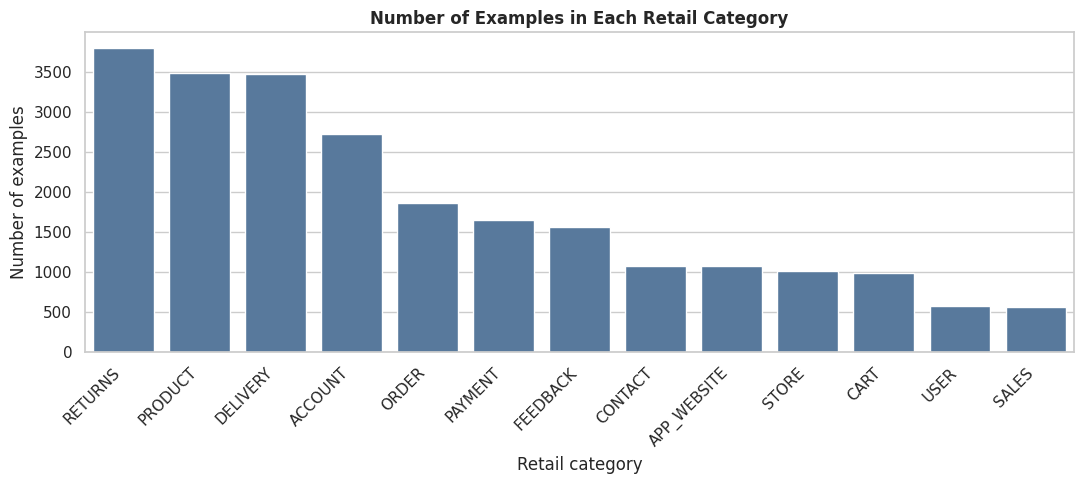

In [21]:
# Chart 1: Retail-category distribution.
plt.figure(figsize=(11, 5))
category_counts = eda_df["category"].value_counts()
sns.barplot(x=category_counts.index, y=category_counts.values, color="#4C78A8")
plt.title("Number of Examples in Each Retail Category", fontweight="bold")
plt.xlabel("Retail category")
plt.ylabel("Number of examples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Chart 1: Category distribution

**Why this chart?** A bar chart compares the amount of training data available for each retail category.

**How to interpret it:** After running it, identify the most and least represented categories. Categories with fewer examples may receive less reliable model responses because the model sees fewer examples during fine-tuning.

**Business relevance:** The chart helps identify support areas where extra verified examples would improve coverage.


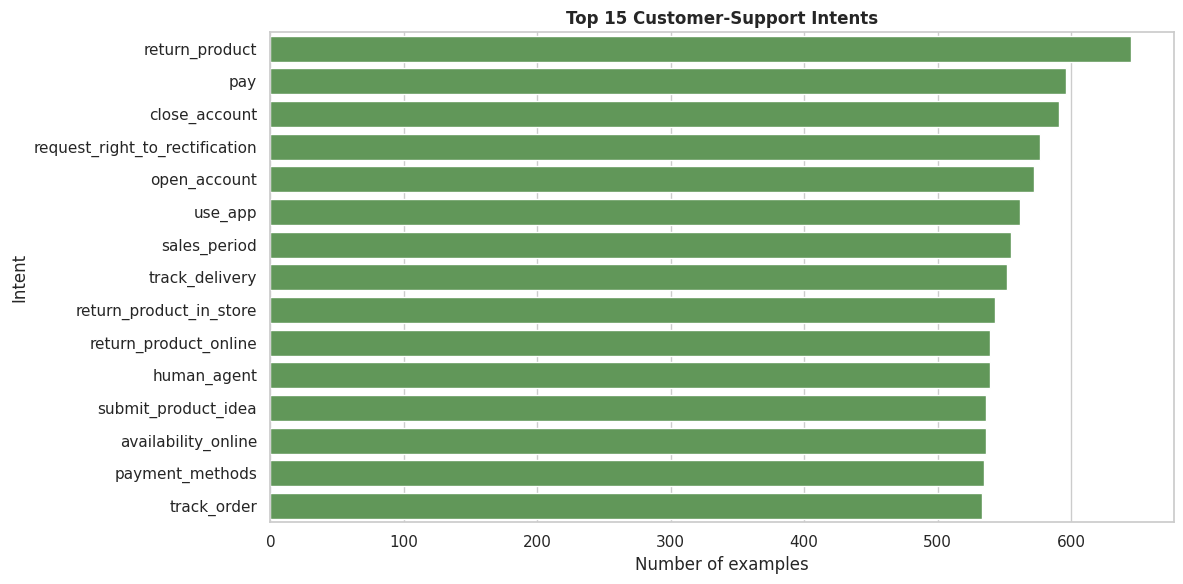

In [22]:
# Chart 2: Most common customer-support intents.
top_intents = eda_df["intent"].value_counts().head(15)
plt.figure(figsize=(12, 6))
sns.barplot(y=top_intents.index, x=top_intents.values, color="#59A14F")
plt.title("Top 15 Customer-Support Intents", fontweight="bold")
plt.xlabel("Number of examples")
plt.ylabel("Intent")
plt.tight_layout()
plt.show()


### Chart 2: Common support intents

**Why this chart?** A horizontal bar chart is readable when intent labels are long.

**How to interpret it:** The most frequent intents represent common customer requests. Use them when selecting questions for the live bot demonstration.

**Business relevance:** A support bot should be especially dependable for high-volume questions because these have the greatest potential to reduce repetitive support work.


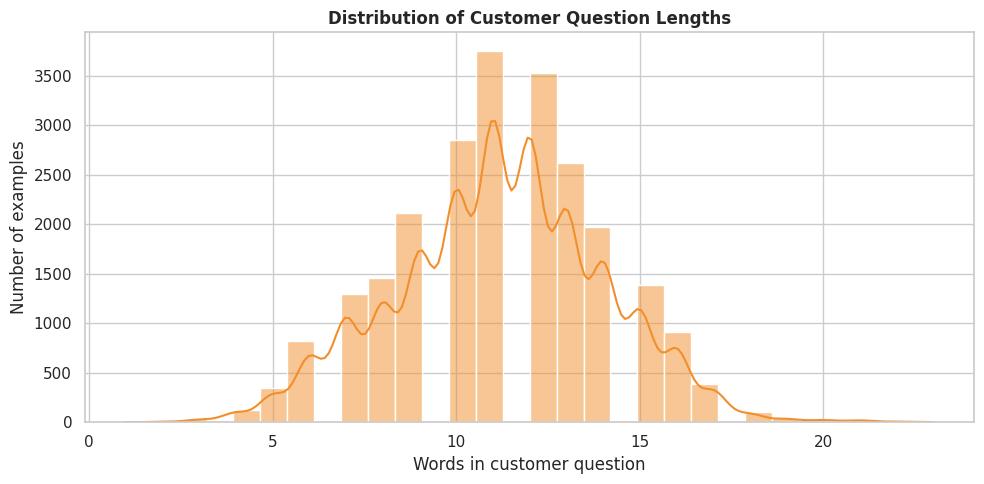

In [23]:
# Chart 3: Customer-question length.
plt.figure(figsize=(10, 5))
sns.histplot(eda_df["question_word_count"], bins=30, color="#F28E2B", kde=True)
plt.title("Distribution of Customer Question Lengths", fontweight="bold")
plt.xlabel("Words in customer question")
plt.ylabel("Number of examples")
plt.tight_layout()
plt.show()


### Chart 3: Customer-question length

**Why this chart?** A histogram shows whether customer messages are mainly short, detailed, or highly variable.

**How to interpret it:** Retail questions are often brief and informal. The bot should therefore be tested with both concise questions and more detailed requests.

**Business relevance:** Understanding typical input length helps choose realistic test prompts and conversation design.


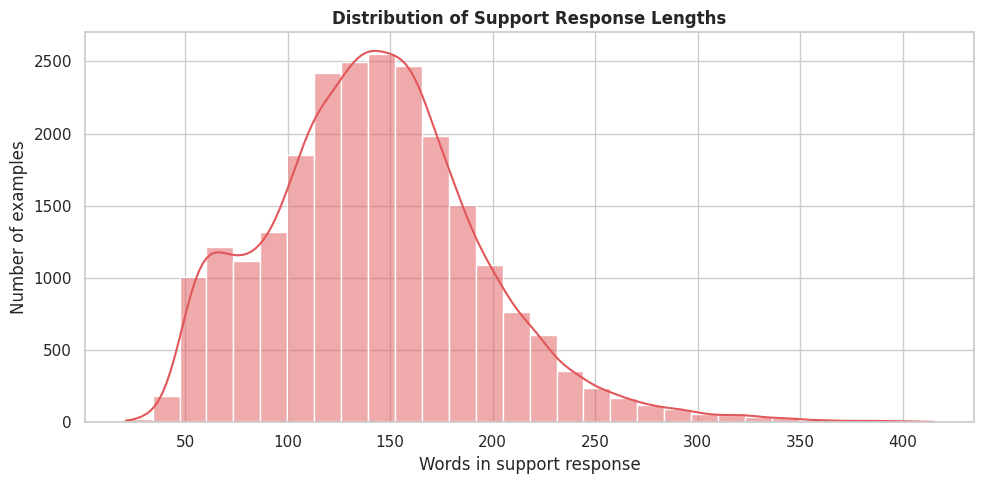

In [24]:
# Chart 4: Support-response length.
plt.figure(figsize=(10, 5))
sns.histplot(eda_df["response_word_count"], bins=30, color="#E15759", kde=True)
plt.title("Distribution of Support Response Lengths", fontweight="bold")
plt.xlabel("Words in support response")
plt.ylabel("Number of examples")
plt.tight_layout()
plt.show()


### Chart 4: Support-response length

**Why this chart?** This chart shows whether the original support answers are normally brief or step-by-step.

**How to interpret it:** Long answers may be cut off if the sequence length is too small. The response-length distribution supports the choice of a 256-token fast setting or a 384-token final setting.

**Business relevance:** More complete answers can reduce follow-up questions, while excessively long answers may be harder for customers to use.


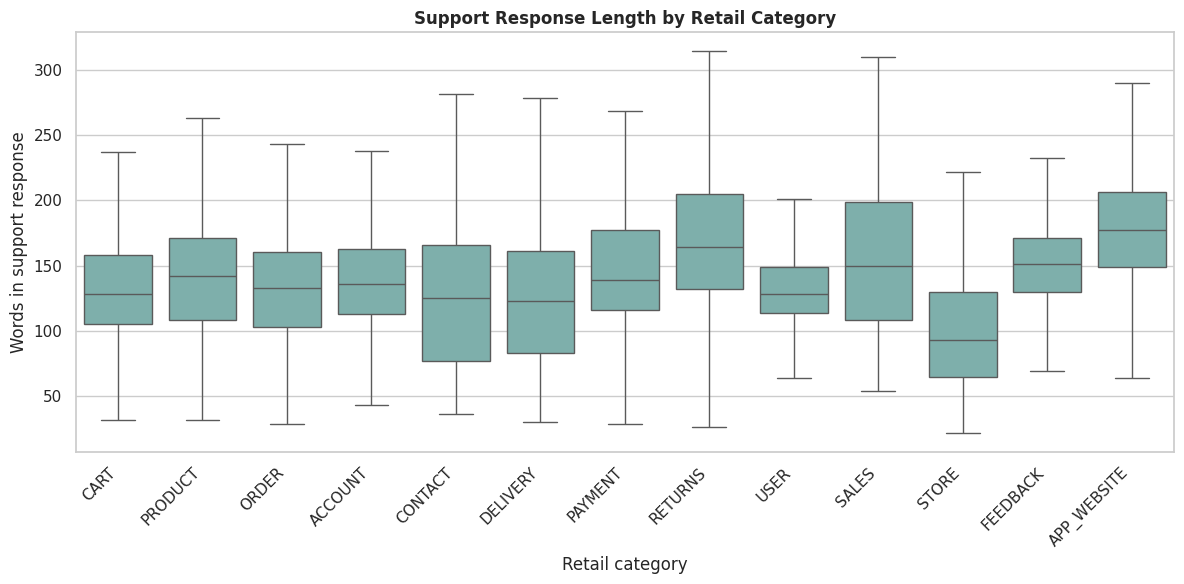

In [25]:
# Chart 5: Response length across retail categories.
plt.figure(figsize=(12, 6))
sns.boxplot(data=eda_df, x="category", y="response_word_count", color="#76B7B2", showfliers=False)
plt.title("Support Response Length by Retail Category", fontweight="bold")
plt.xlabel("Retail category")
plt.ylabel("Words in support response")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Chart 5: Response length by category

**Why this chart?** A box plot compares the typical response length and variation across several categories.

**How to interpret it:** Categories with longer responses may involve more complicated procedures, such as returns, payments, or delivery problems.

**Business relevance:** These topics should receive extra attention during testing because incomplete guidance can leave customers dissatisfied.


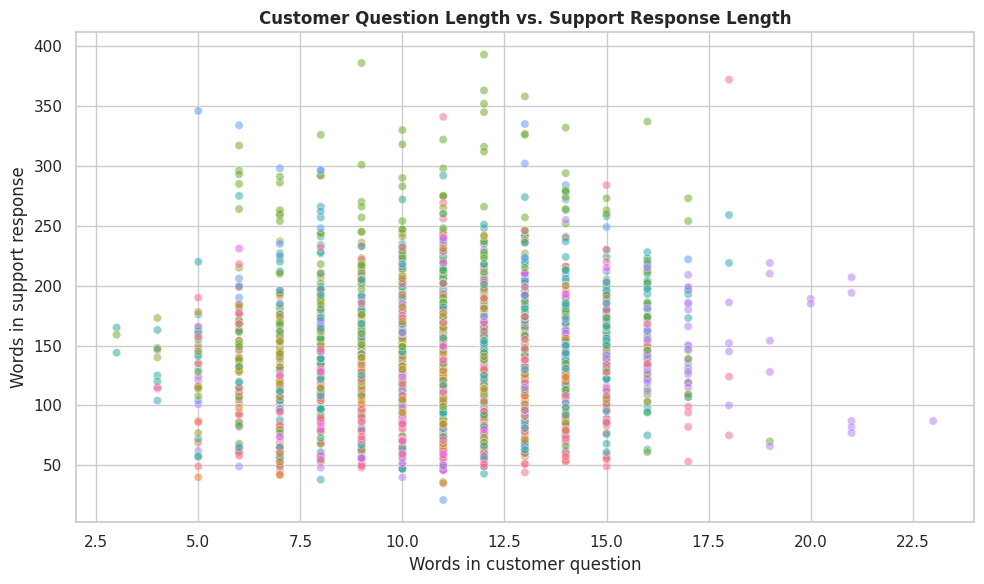

In [26]:
# Chart 6: Relationship between question and response length.
plot_sample = eda_df.sample(min(2500, len(eda_df)), random_state=SEED)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_sample,
    x="question_word_count",
    y="response_word_count",
    hue="category",
    alpha=0.55,
    legend=False,
)
plt.title("Customer Question Length vs. Support Response Length", fontweight="bold")
plt.xlabel("Words in customer question")
plt.ylabel("Words in support response")
plt.tight_layout()
plt.show()


### Chart 6: Question length versus response length

**Why this chart?** A scatter plot reveals whether more detailed customer questions tend to receive more detailed answers.

**How to interpret it:** Look for the overall pattern after running the chart. A weak relationship can mean that some retail topics require long procedural guidance even when the customer question is short.

**Business relevance:** This supports a bot design that gives sufficient guidance without assuming that a short question always needs a short answer.


## EDA summary

After running the charts, replace the bracketed sections below with your own observations.

The cleaned dataset contains **[insert result]** examples, **[insert result]** retail categories, and **[insert result]** customer-support intents. The category and intent distributions show that **[write your actual observation]**. The text-length analysis indicates that customer questions are generally **[short / medium / varied]**, while support answers are **[brief / detailed / varied]**.

Based on these findings, the project uses a maximum sequence length of **[256 or 384]** tokens. This setting is a balance between retaining useful response content and keeping QLoRA training practical on a Google Colab T4 GPU.


## 5. Data augmentation decision

Data augmentation was considered but was not used in the main training run. The original public dataset already contains tens of thousands of retail-support examples. Creating synthetic support answers could introduce inaccurate return, payment, or delivery advice. If the project is expanded later, only manually reviewed paraphrases of customer questions should be added while retaining verified support answers.


## 6. Model selection and training approach

[TinyLlama-1.1B-Chat-v1.0](https://huggingface.co/TinyLlama/TinyLlama-1.1B-Chat-v1.0) was selected because it is a compact chat model that fits the resource limits of a Google Colab T4 GPU. The model is loaded in 4-bit mode and fine-tuned with LoRA adapters rather than updating every original parameter. This QLoRA approach reduces memory use while allowing the model to adapt to retail-support language.

The notebook provides a fast first-run configuration and a larger final configuration. Both are well below the maximum limit of 25 training epochs.


In [27]:
# Fast mode is useful for confirming that the complete notebook works.
# Change FAST_MODE to False for the final, stronger run.
FAST_MODE = True

MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
MAX_SAMPLES = 1500 if FAST_MODE else 3000
MAX_LENGTH = 256 if FAST_MODE else 384
EPOCHS = 2 if FAST_MODE else 3
TRAIN_BATCH_SIZE = 4 if FAST_MODE else 2
GRADIENT_ACCUMULATION = 4 if FAST_MODE else 8

# Shuffle before selecting a smaller, representative training pool.
data = cleaned_data.shuffle(seed=SEED).select(range(min(MAX_SAMPLES, len(cleaned_data))))
print(f"Mode: {'FAST' if FAST_MODE else 'FINAL'}")
print("Examples selected:", len(data))
print("Maximum sequence length:", MAX_LENGTH)
print("Epochs:", EPOCHS)


Mode: FAST
Examples selected: 1500
Maximum sequence length: 256
Epochs: 2


In [28]:
# TinyLlama's built-in chat template is used in both training and generation.
# This keeps the prompt format consistent from beginning to end.
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

def tokenize_example(example):
    user_message = [{"role": "user", "content": example["instruction"]}]
    full_conversation = [
        {"role": "user", "content": example["instruction"]},
        {"role": "assistant", "content": example["response"]},
    ]

    prompt_text = tokenizer.apply_chat_template(
        user_message,
        tokenize=False,
        add_generation_prompt=True,
    )
    full_text = tokenizer.apply_chat_template(
        full_conversation,
        tokenize=False,
        add_generation_prompt=False,
    )

    prompt_ids = tokenizer(
        prompt_text,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LENGTH,
    )["input_ids"]

    model_inputs = tokenizer(
        full_text,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LENGTH,
    )

    # Ignore the customer prompt in the loss; learn only the assistant answer.
    labels = model_inputs["input_ids"].copy()
    prompt_length = min(len(prompt_ids), len(labels))
    labels[:prompt_length] = [-100] * prompt_length
    model_inputs["labels"] = labels
    return model_inputs

tokenized_data = data.map(
    tokenize_example,
    remove_columns=data.column_names,
    desc="Tokenising retail conversations",
)

# Remove any example where truncation removed the entire target answer.
tokenized_data = tokenized_data.filter(
    lambda row: any(token != -100 for token in row["labels"])
)

splits = tokenized_data.train_test_split(test_size=0.10, seed=SEED)
train_dataset = splits["train"]
eval_dataset = splits["test"]

print("Training examples:", len(train_dataset))
print("Validation examples:", len(eval_dataset))


Training examples: 1350
Validation examples: 150


In [29]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print("Loading TinyLlama in 4-bit mode...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
)

model.config.use_cache = False
model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=not FAST_MODE,
)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


Loading TinyLlama in 4-bit mode...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

trainable params: 4,505,600 || all params: 1,104,553,984 || trainable%: 0.4079


In [16]:
import inspect

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    padding=True,
    label_pad_token_id=-100,
    pad_to_multiple_of=8,
)

# Check which TrainingArguments options exist in your installed Transformers version.
supported_args = inspect.signature(TrainingArguments.__init__).parameters

training_kwargs = {
    "output_dir": "./retail_tinyllama_results",
    "num_train_epochs": EPOCHS,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION,
    "learning_rate": 2e-4,
    "warmup_steps": 10 if FAST_MODE else 25,
    "fp16": True,
    "logging_steps": 20,
    "seed": SEED,
}

# Different Transformers versions use different batch-size argument names.
if "per_device_train_batch_size" in supported_args:
    training_kwargs["per_device_train_batch_size"] = TRAIN_BATCH_SIZE
    training_kwargs["per_device_eval_batch_size"] = TRAIN_BATCH_SIZE
else:
    training_kwargs["per_gpu_train_batch_size"] = TRAIN_BATCH_SIZE
    training_kwargs["per_gpu_eval_batch_size"] = TRAIN_BATCH_SIZE

# Add these only when your installed version supports them.
optional_args = {
    "lr_scheduler_type": "cosine",
    "optim": "paged_adamw_8bit",
    "group_by_length": True,
    "report_to": "none",
    "do_train": True,
    "do_eval": True,
}

for argument, value in optional_args.items():
    if argument in supported_args:
        training_kwargs[argument] = value

training_args = TrainingArguments(**training_kwargs)

print("Using TrainingArguments:")
print(training_args)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
)

print("Starting fine-tuning...")
trainer.train()

print("\nValidation results:")
validation_results = trainer.evaluate()
print(validation_results)

Using TrainingArguments:
TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_in_order=True,
dataloader_multiprocessing_context=None,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=True,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_bat

Step,Training Loss
20,1.098524
40,0.876269
60,0.815858
80,0.779293
100,0.743893
120,0.713703
140,0.710852
160,0.688397



Validation results:


Training Loss,Validation Loss,Step
0.688397,0.702505,170


{'eval_loss': 0.7025051116943359}


## 7. Saving the adapter and developing the bot

The trained LoRA adapter and tokenizer are saved so that the retail bot can be loaded again without retraining. The bot function below uses the same TinyLlama chat template as the training process. It decodes only newly generated text, preventing the customer prompt from being repeated in the final answer.


In [30]:
ADAPTER_DIR = "./retail_tinyllama_adapter"
trainer.save_model(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"Adapter and tokenizer saved to: {ADAPTER_DIR}")

model.config.use_cache = True
model.eval()

def ask_retail_bot(customer_question, max_new_tokens=160):
    """Return a general retail-support answer for one customer question."""
    messages = [{"role": "user", "content": customer_question}]
    prompt_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt_text,
        return_tensors="pt",
        add_special_tokens=False,
    ).to(model.device)

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.12,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


Adapter and tokenizer saved to: ./retail_tinyllama_adapter


## 8. Testing and evaluation

The bot is tested with questions from different retail-support areas. The goal is not merely to generate text; responses should be relevant, coherent, polite, and honest about the bot's limitations. In particular, the bot should provide general guidance rather than claiming to access live orders or private customer accounts.


In [31]:
test_questions = [
    "How do I add an item to my cart?",
    "Can I return a jacket if it does not fit me?",
    "How can I update my shipping address before my order is sent?",
    "My delivery is taking longer than expected. What should I do?",
    "What payment methods can I use at checkout?",
]

print("--- RETAIL BOT TEST ---")
for question in test_questions:
    print(f"\nCustomer: {question}")
    print(f"Bot: {ask_retail_bot(question)}")
    print("-" * 80)


[transformers] Both `max_new_tokens` (=160) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- RETAIL BOT TEST ---

Customer: How do I add an item to my cart?


[transformers] Both `max_new_tokens` (=160) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Bot: To add an item to your cart in the Magento 2 shopping cart, follow these steps:

1. Log in to your admin panel (admin.yourdomain.com) and navigate to the "Shopping Cart" section.

2. Click on the "Add to Cart" button for the product you want to add to your cart. This will take you to a page where you can choose which quantity of the product you would like to purchase.

3. Enter the desired quantity into the quantity field.

4. Once you have entered the quantity, click "Update Cart."

5. Your selected product will now be added to your cart. You can then proceed with adding more items to your cart as needed.

Note: If
--------------------------------------------------------------------------------

Customer: Can I return a jacket if it does not fit me?


[transformers] Both `max_new_tokens` (=160) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Bot: Yes, you can return a jacket that does not fit you as long as it is in its original condition and packaging. The manufacturer may have specific policies regarding returns or exchanges for non-fitting items. You should check the manufacturer's policy before making any purchases to ensure that it covers your situation. Additionally, it is always best to contact the manufacturer directly to ask about their return policy for non-fitting items.  If you are unsure about your rights under the manufacturer's return policy, you may want to seek advice from a legal professional or contact customer service.
--------------------------------------------------------------------------------

Customer: How can I update my shipping address before my order is sent?


[transformers] Both `max_new_tokens` (=160) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Bot: To update your shipping address before your order is sent, follow these steps:
1. Log in to your account on our website.
2. Click on "My Account" on the top right corner of the homepage.
3. Go to the "Orders and Shipping" section at the bottom of the page.
4. Select the order you want to update.
5. Look for an option to "Update Ship To Address".
6. Click on this option to update your shipping information.
7. Fill in your new shipping details (such as a different address or phone number) and click "Save Changes."
8. Your updated shipping information will be reflected on your order status.
If you need to update any other
--------------------------------------------------------------------------------

Customer: My delivery is taking longer than expected. What should I do?


[transformers] Both `max_new_tokens` (=160) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Bot: If your delivery is taking longer than usual, you may want to consider the following:

1. Check the address: Make sure that the address provided by the delivery service is correct and accurate. If it's incorrect or incomplete, it can delay your package.

2. Contact the delivery service: You can contact the delivery service directly to inquire about any issues with your address or tracking information. They may be able to help resolve the issue and get your package on its way more quickly.

3. Schedule a delivery appointment: Depending on the type of delivery service you are using, you may have an option to schedule a delivery appointment at a later time to expedite the process. This will give them more time to pick up and deliver your package.

4
--------------------------------------------------------------------------------

Customer: What payment methods can I use at checkout?
Bot: Yes, you can use various payment methods at checkout depending on your chosen online store's webs

In [32]:
# using gradio for temporary deployment to test the bot
import gradio as gr

demo = gr.Interface(
    fn=ask_retail_bot,
    inputs=gr.Textbox(
        lines=3,
        label="Retail question",
        placeholder="Example: Can I return an item that does not fit?",
    ),
    outputs=gr.Textbox(lines=8, label="Retail support bot response"),
    title="IndustryGPT: Retail and E-Commerce Support Bot",
    description="This demonstration bot gives general retail-support guidance. It cannot access real orders or customer accounts.",
)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c8682fb78b42def560.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Results, limitations, and conclusion

Complete this section only after running the notebook and reviewing the output.

The model was fine-tuned for **[insert completed epoch count]** epochs on **[insert number]** cleaned retail-support examples. The final validation loss was **[insert your actual value]**. During manual testing, the bot handled questions about **[list the topics you tested]**. The strongest responses were **[describe a real strength from your own output]**.

One limitation observed during testing was **[describe a real weakness, such as repetition, vague wording, or a missing policy detail]**. The model has learned patterns from public examples, but it does not have access to a company's live inventory, orders, payments, or customer accounts. A real deployment would require approved company policies, retrieval from an up-to-date knowledge base, stronger safety rules, and human escalation for sensitive cases.

Overall, this project demonstrates that a compact pre-trained model can be adapted to a specific industry through relevant data, careful preprocessing, parameter-efficient fine-tuning, and practical testing.
